# HC3 Human vs. ChatGPT: refreshed and expanded EDA

This notebook uses the current cleaning and question-grouped, source-stratified splitting logic. Only training answers drive writing-style exploration. Validation/test are used solely for structural integrity and distribution checks, never feature selection or model tuning. No datasets or other notebooks are overwritten.

Run all cells from the repository root or `notebooks/`, with the dependencies in `requirements.txt`. The raw local `data/hc3_all.csv` is required. Tables and charts are descriptive, not evidence that a feature generalizes to other models or datasets.


## Recreate current preprocessing and splits in memory

The local generated CSVs may predate the Git update. Execute the current cleaning and splitting notebook code in an isolated namespace, suppressing their CSV writes and redirecting their dataset reads to memory. This keeps the analysis aligned with teammates' exact implementation, including answer-list repair, ID handling, and random state 42. Their source notebooks stay untouched. Raw-to-cleaned coverage and stale local split files are reported below.


In [1]:
import ast
import contextlib
import hashlib
import io
import itertools
import json
import re
import string
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
LABELS = ["human", "chatgpt"]
sns.set_theme(style="whitegrid")

class InMemoryPreparation(ast.NodeTransformer):
    def visit_Expr(self, node):
        # Remove file writes; all preprocessing/splitting operations remain intact.
        if isinstance(node.value, ast.Call) and isinstance(node.value.func, ast.Attribute):
            if node.value.func.attr == "to_csv":
                return None
        return self.generic_visit(node)

    def visit_Call(self, node):
        node = self.generic_visit(node)
        if isinstance(node.func, ast.Attribute) and node.func.attr == "read_csv":
            filename = node.args[0].value
            name = "raw_input" if filename.endswith("hc3_all.csv") else "expanded"
            return ast.copy_location(ast.Call(
                func=ast.Attribute(value=ast.Name(id=name, ctx=ast.Load()), attr="copy", ctx=ast.Load()),
                args=[], keywords=[]), node)
        return node

raw_input = pd.read_csv(ROOT / "data/hc3_all.csv")
namespace = {"raw_input": raw_input}
preparation_log = io.StringIO()
for filename in ["data_cleaning.ipynb", "dataset_splitting.ipynb"]:
    notebook = json.loads((ROOT / "notebooks" / filename).read_text())
    with contextlib.redirect_stdout(preparation_log):
        for cell in notebook["cells"]:
            if cell["cell_type"] == "code":
                tree = InMemoryPreparation().visit(ast.parse("".join(cell["source"])))
                exec(compile(ast.fix_missing_locations(tree), filename, "exec"), namespace)

expanded = namespace["expanded"].copy()
splits = {name: namespace[name].copy() for name in ["train", "validation", "test"]}
answers = splits["train"].copy().reset_index(drop=True)
print("Raw CSV SHA-256:", hashlib.sha256((ROOT / "data/hc3_all.csv").read_bytes()).hexdigest())
print(f"Raw questions: {len(raw_input):,}; retained: {namespace['clean']['id'].nunique():,}; answer rows: {len(expanded):,}")
print("Cleaning/splitting code replayed in memory; no CSV files written.")
asset_checks = []
for name, expected in splits.items():
    path = ROOT / "data/processed" / (name + ".csv")
    saved = pd.read_csv(path) if path.exists() else None
    matches = False
    if saved is not None:
        try:
            pd.testing.assert_frame_equal(saved, expected.reset_index(drop=True), check_dtype=False)
            matches = True
        except AssertionError:
            pass
    asset_checks.append({"split": name, "saved_csv_matches_current_pipeline": matches})
display(pd.DataFrame(asset_checks))


Raw CSV SHA-256: a0bf93fe1e7769bd2b9dbb687060cdf9ddcfbea50a2649d48391781af8b74c44
Raw questions: 24,322; retained: 23,867; answer rows: 84,066
Cleaning/splitting code replayed in memory; no CSV files written.


,split,saved_csv_matches_current_pipeline
0,train,True
1,validation,True
2,test,True


## Split integrity, coverage, and class/domain balance

Question IDs must be disjoint; every retained answer must belong to exactly one split. Source stratification applies to questions, so answer proportions and class proportions can differ slightly. Report both units. Missing values and invalid label/target pairs are checked before feature analysis.


,answers,questions,answer_percent,question_percent,human_percent
split,,,,,
train,67232,19093,79.98,80.0,68.04
validation,8417,2387,10.01,10.0,67.95
test,8417,2387,10.01,10.0,67.95


,pair,shared_question_ids
0,train/validation,0
1,train/test,0
2,validation/test,0


,train,validation,test
source,,,
reddit_eli5,69.79,69.79,69.79
finance,16.48,16.46,16.51
medicine,5.23,5.24,5.24
open_qa,4.98,4.99,4.94
wiki_csai,3.53,3.52,3.52


,train,validation,test
source,,,
reddit_eli5,79.28,79.17,79.17
finance,10.01,10.1,10.13
open_qa,5.64,5.63,5.58
medicine,3.06,3.1,3.11
wiki_csai,2.0,2.0,2.0


label,human,chatgpt
source,,
finance,3146,3587
medicine,998,1061
open_qa,950,2839
reddit_eli5,39975,13328
wiki_csai,674,674


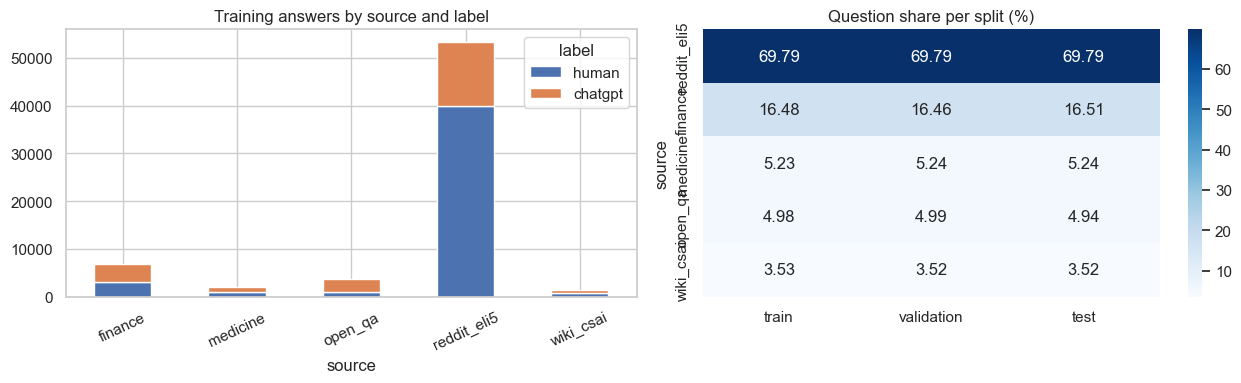

In [2]:
required = ["id", "question", "source", "text", "label", "target"]
assert set(required).issubset(expanded.columns)
assert not expanded[required].isna().any().any()
assert expanded["text"].str.strip().ne("").all()
assert expanded["label"].isin(LABELS).all()
assert expanded["target"].eq(expanded["label"].map({"human": 0, "chatgpt": 1})).all()
assert expanded.groupby("id")["source"].nunique().eq(1).all()
assert sum(map(len, splits.values())) == len(expanded)
assert pd.concat(splits.values()).sort_index().equals(expanded)

split_summary = pd.DataFrame([
    {"split": name, "answers": len(frame), "questions": frame["id"].nunique(),
     "answer_percent": len(frame) / len(expanded) * 100,
     "question_percent": frame["id"].nunique() / expanded["id"].nunique() * 100,
     "human_percent": frame["label"].eq("human").mean() * 100}
    for name, frame in splits.items()
]).set_index("split")
display(split_summary.round(2))
overlap = []
for a, b in itertools.combinations(splits, 2):
    count = len(set(splits[a]["id"]) & set(splits[b]["id"]))
    overlap.append({"pair": f"{a}/{b}", "shared_question_ids": count})
assert all(row["shared_question_ids"] == 0 for row in overlap)
display(pd.DataFrame(overlap))
source_question_pct = pd.DataFrame({name: frame.drop_duplicates("id")["source"].value_counts(normalize=True) * 100 for name, frame in splits.items()})
source_answer_pct = pd.DataFrame({name: frame["source"].value_counts(normalize=True) * 100 for name, frame in splits.items()})
display(source_question_pct.round(2), source_answer_pct.round(2))
source_labels = pd.crosstab(answers["source"], answers["label"]).reindex(columns=LABELS)
display(source_labels)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
source_labels.plot.bar(stacked=True, ax=axes[0], rot=25, title="Training answers by source and label")
sns.heatmap(source_question_pct.astype(float), annot=True, fmt=".2f", ax=axes[1], cmap="Blues")
axes[1].set_title("Question share per split (%)")
plt.tight_layout(); plt.show()


## Duplicate text, conflicting labels, and residual leakage

Different question IDs can still share identical prompts or answers. Compare exact answers and a conservative lowercase/whitespace-normalized key across splits; these checks do not detect semantic near-duplicates. Counts below measure distinct shared keys, not overlapping rows. Conflicting labels are an audit flag, not grounds for automatic deletion.


In [3]:
audit = expanded.copy()
audit["normalized_text"] = audit["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
duplicate_summary = pd.DataFrame([
    {"key": key, "repeated_rows_beyond_first": audit.duplicated(key).sum(),
     "distinct_repeated_keys": audit.loc[audit.duplicated(key, keep=False), key].nunique(),
     "keys_with_both_labels": audit.groupby(key)["label"].nunique().gt(1).sum()}
    for key in ["text", "normalized_text"]
])
display(duplicate_summary)
leakage_rows = []
for a, b in itertools.combinations(splits, 2):
    left, right = splits[a], splits[b]
    norm = lambda s: s.str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    leakage_rows.append({"pair": f"{a}/{b}",
        "exact_answer_keys": len(set(left["text"]) & set(right["text"])),
        "normalized_answer_keys": len(set(norm(left["text"])) & set(norm(right["text"]))),
        "normalized_prompt_keys": len(set(norm(left["question"])) & set(norm(right["question"])))})
leakage_table = pd.DataFrame(leakage_rows)
display(leakage_table)
print("Residual answer/prompt overlap should be reviewed before interpreting model scores; no records are altered here.")


,key,repeated_rows_beyond_first,distinct_repeated_keys,keys_with_both_labels
0,text,5191,5076,0
1,normalized_text,5192,5076,0


,pair,exact_answer_keys,normalized_answer_keys,normalized_prompt_keys
0,train/validation,788,788,92
1,train/test,879,879,105
2,validation/test,92,92,4


Residual answer/prompt overlap should be reviewed before interpreting model scores; no records are altered here.


## Answer Length

### Compare character, word, and sentence counts

Check whether one group writes longer answers. The mean is the average; the median is the middle value and is less affected by very long answers. Characters include spaces, words use letter-based tokens, and sentence boundaries are estimated from punctuation.

character_count                    word_count                   \
                   mean  median min    max       mean median min   max   
label                                                                    
chatgpt         1008.14  1010.0  16   3508     174.16  175.0   2   632   
human            687.75   425.0   9  36793     118.85   74.0   0  5757   

        sentence_count                  
                  mean median min  max  
label                                   
chatgpt           7.07    7.0   1   32  
human             6.65    4.0   1  369

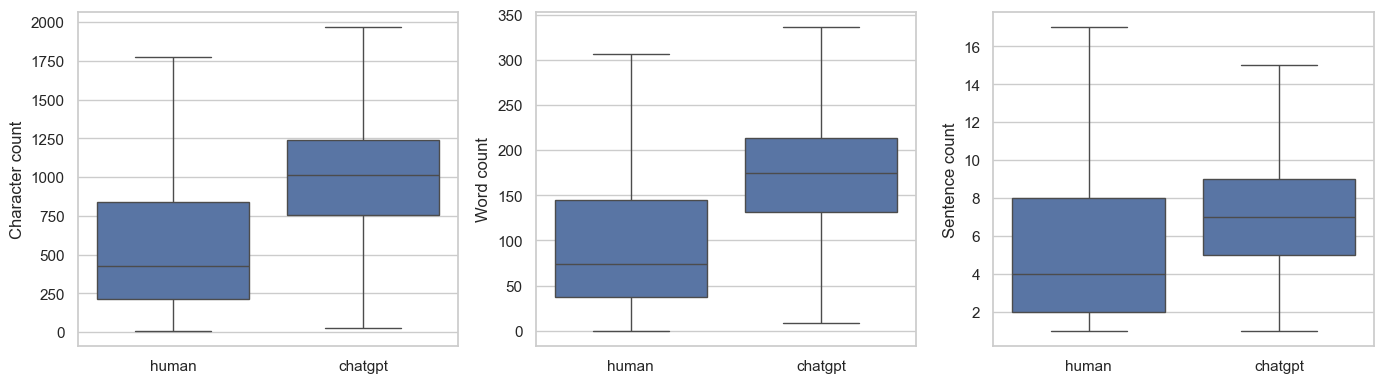

In [4]:
word_pattern = re.compile(r"[^\W\d_]+(?:['’][^\W\d_]+)*", re.UNICODE)
tokens = answers["text"].map(lambda text: word_pattern.findall(text.lower()))

def sentence_count(text):
    pieces = re.split(r"[.!?]+[\"'’”)]*(?:\s+|$)", text.strip())
    return sum(bool(re.search(r"\w", piece)) for piece in pieces)

answers["character_count"] = answers["text"].str.len()
answers["word_count"] = tokens.map(len)
answers["sentence_count"] = answers["text"].map(sentence_count)
length_columns = ["character_count", "word_count", "sentence_count"]
length_summary = answers.groupby("label")[length_columns].agg(["mean", "median", "min", "max"])
display(length_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, column in zip(axes, length_columns):
    sns.boxplot(data=answers, x="label", y=column, order=LABELS, showfliers=False, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(column.replace("_", " ").capitalize())
plt.tight_layout()
plt.show()

### Read the length plots

The line inside each box is the median; the box contains the middle 50% of answers. Outlier points are hidden, but included in the tables. Large length differences could give the classifier an easy shortcut.

## Vocabulary

### Compare unique words and repetition

Count distinct lowercase words and calculate unique words divided by total words. For example, 60 unique words in a 100-word answer gives a ratio of 0.60.

unique_word_count        unique_word_ratio       
                     mean median              mean median
label                                                    
chatgpt            87.941   88.0             0.531  0.522
human              69.820   54.0             0.722  0.724

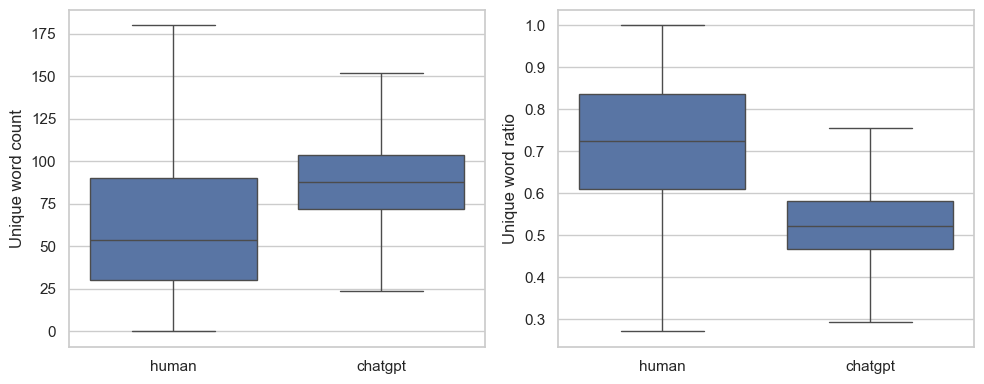

In [5]:
answers["unique_word_count"] = tokens.map(lambda words: len(set(words)))
answers["unique_word_ratio"] = answers["unique_word_count"] / answers["word_count"].replace(0, float("nan"))
vocabulary_columns = ["unique_word_count", "unique_word_ratio"]
display(answers.groupby("label")[vocabulary_columns].agg(["mean", "median"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, column in zip(axes, vocabulary_columns):
    sns.boxplot(data=answers, x="label", y=column, order=LABELS, showfliers=False, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(column.replace("_", " ").capitalize())
plt.tight_layout()
plt.show()

### Compare the most frequent words

Show the top 15 words in each group. Each bar gives occurrences per 10,000 words, making groups with different amounts of text easier to compare. Common words are kept because they can reveal writing patterns.

,word,count,per_10000_words,label
0,the,285282,524.74,human
1,to,155334,285.72,human
2,a,147308,270.95,human
3,of,129735,238.63,human
4,and,125608,231.04,human
5,is,100481,184.82,human
6,you,89235,164.14,human
7,it,88267,162.36,human
8,in,84020,154.54,human
9,that,81458,149.83,human


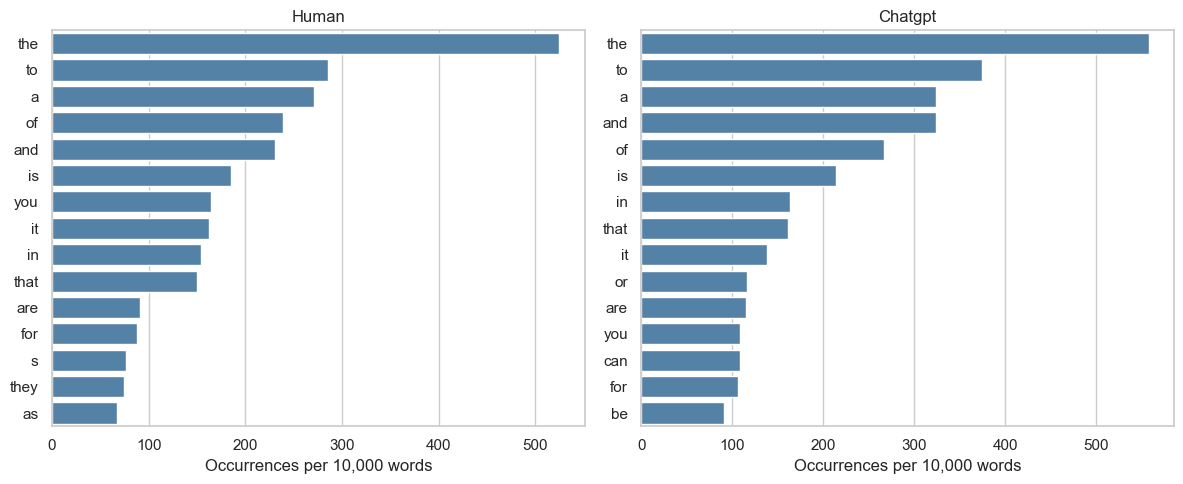

In [6]:
frequency_tables = []
for label in LABELS:
    counts = Counter(word for words in tokens[answers["label"].eq(label)] for word in words)
    table = pd.DataFrame(counts.most_common(15), columns=["word", "count"])
    table["per_10000_words"] = table["count"] / sum(counts.values()) * 10000
    table["label"] = label
    frequency_tables.append(table)

word_frequencies = pd.concat(frequency_tables, ignore_index=True)
display(word_frequencies.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label in zip(axes, LABELS):
    subset = word_frequencies[word_frequencies["label"].eq(label)]
    sns.barplot(data=subset, x="per_10000_words", y="word", color="steelblue", ax=ax)
    ax.set_title(label.capitalize())
    ax.set_xlabel("Occurrences per 10,000 words")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Punctuation and Structure

### Compare punctuation and symbol usage

Compare commas, periods, question marks, and other symbols. Counts show total usage per answer; rates per 100 words account for answer length. Bars show the average per-answer rate. Apostrophes include contractions; periods include decimals and abbreviations. Other symbols cover remaining ASCII punctuation and the Unicode ellipsis.

commas        periods        question_marks        exclamation_marks  \
          mean median    mean median           mean median              mean   
label                                                                          
chatgpt   8.52    8.0    7.93    8.0           0.07    0.0              0.14   
human     5.55    3.0    6.73    4.0           0.23    0.0              0.11   

               colons        semicolons        parentheses         \
        median   mean median       mean median        mean median   
label                                                               
chatgpt    0.0   0.68    0.0       0.01    0.0        0.84    0.0   
human      0.0   0.40    0.0       0.11    0.0        1.99    0.0   

        hyphens_dashes        quotes_apostrophes        other_symbols         
                  mean median               mean median          mean median  
label                                                                         
chatgpt           0.79    0.0               2.35    1.0          1.01    0.0  
human             1.05    0.0               3.40    2.0          2.19    0.0

label,chatgpt,human
commas,5.00,4.32
periods,4.66,6.43
question_marks,0.06,0.30
exclamation_marks,0.11,0.12
colons,0.31,0.35
semicolons,0.00,0.09
parentheses,0.46,1.67
hyphens_dashes,0.44,0.73
quotes_apostrophes,1.44,3.03
other_symbols,0.56,2.21


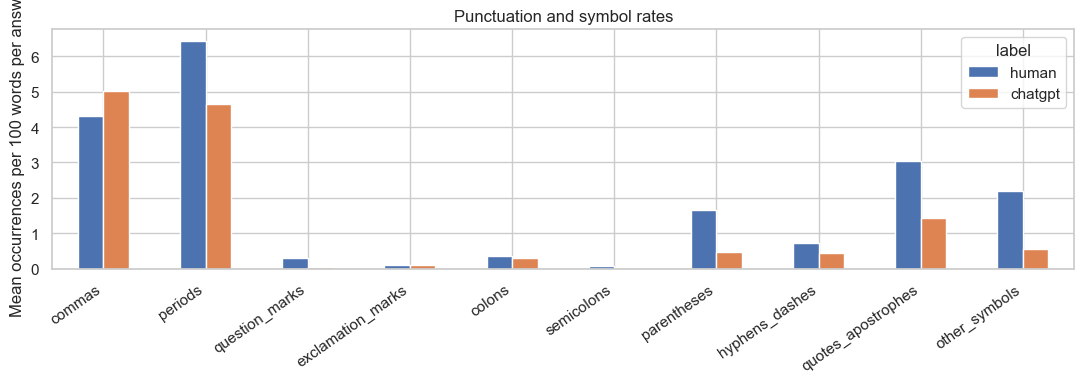

In [7]:
symbols = {
    "commas": ",", "periods": ".", "question_marks": "?", "exclamation_marks": "!",
    "colons": ":", "semicolons": ";", "parentheses": "()", "hyphens_dashes": "-–—",
    "quotes_apostrophes": "\"'‘’“”",
}
covered = set("".join(symbols.values()))
symbols["other_symbols"] = "".join(sorted((set(string.punctuation) | {"…"}) - covered))

for name, characters in symbols.items():
    answers[name] = answers["text"].str.count("[" + re.escape(characters) + "]")
    answers[name + "_per_100_words"] = answers[name] / answers["word_count"].replace(0, float("nan")) * 100

punctuation_columns = list(symbols)
rate_columns = [name + "_per_100_words" for name in symbols]
display(answers.groupby("label")[punctuation_columns].agg(["mean", "median"]).round(2))
punctuation_rates = answers.groupby("label")[rate_columns].mean().T
punctuation_rates.index = punctuation_columns
display(punctuation_rates.round(2))
punctuation_rates[LABELS].plot(kind="bar", figsize=(11, 4))
plt.xlabel("")
plt.ylabel("Mean occurrences per 100 words per answer")
plt.title("Punctuation and symbol rates")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Compare paragraphs and line breaks

A paragraph is a nonempty block separated by a blank line. The chart shows the percentage of answers with multiple paragraphs. Differences may reflect how the dataset stores text, as well as writing style.

paragraph_count        line_break_count       
                   mean median             mean median
label                                                 
chatgpt            1.76    1.0             1.91    0.0
human              1.01    1.0             0.07    0.0

label
chatgpt    24.85
human       0.06
Name: multiple_paragraphs_percent, dtype: float64

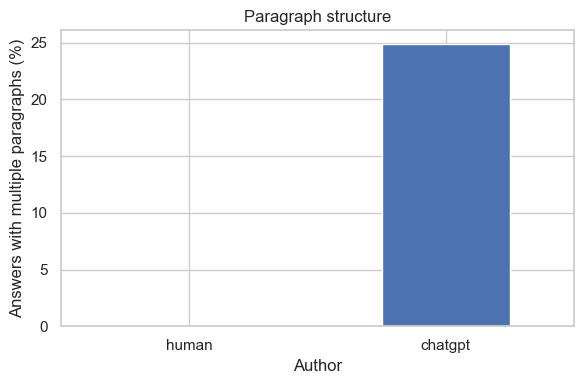

In [8]:
def paragraph_count(text):
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return sum(bool(block.strip()) for block in re.split(r"\n[ \t]*\n+", text.strip()))

answers["paragraph_count"] = answers["text"].map(paragraph_count)
answers["line_break_count"] = answers["text"].str.count(r"\r\n|\r|\n")
answers["multiple_paragraphs"] = answers["paragraph_count"].gt(1)
display(answers.groupby("label")[["paragraph_count", "line_break_count"]].agg(["mean", "median"]).round(2))
paragraph_percent = answers.groupby("label")["multiple_paragraphs"].mean() * 100
display(paragraph_percent.rename("multiple_paragraphs_percent").round(2))
paragraph_percent.reindex(LABELS).plot(kind="bar", figsize=(6, 4), rot=0)
plt.xlabel("Author")
plt.ylabel("Answers with multiple paragraphs (%)")
plt.title("Paragraph structure")
plt.tight_layout()
plt.show()

### Compare words per sentence

Do human or ChatGPT answers use longer sentences? Divide each answer's word count by its estimated sentence count, then compare the typical answer in each class. The table includes the number of answers measured. Sentence boundaries are estimated from punctuation, so abbreviations, decimals, and missing punctuation can affect the result.

**Use for the project:** sentence length is an understandable candidate writing feature. Check its behavior by domain before assuming the same pattern holds for every topic.


,answers_measured,mean_words_per_sentence,median_words_per_sentence
label,,,
human,45743,18.42,17.0
chatgpt,21489,26.56,23.8


Median words per sentence by domain:


label,human,chatgpt
source,,
finance,18.93,35.83
medicine,16.00,21.57
open_qa,24.00,23.14
reddit_eli5,16.83,22.62
wiki_csai,23.71,23.76


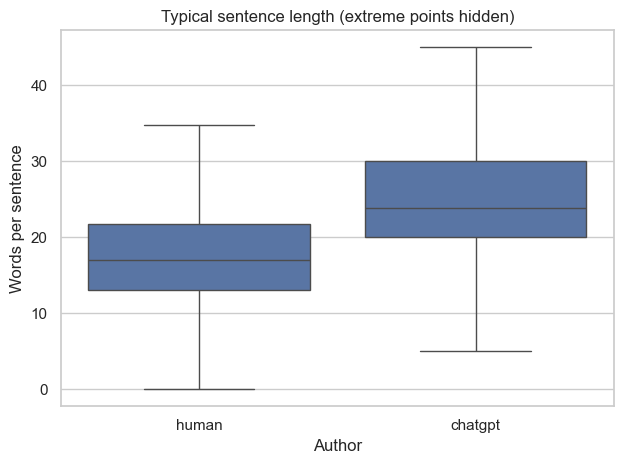

**Reading the result:** the median is 17.0 words per sentence for humans and 23.8 for ChatGPT. The overlapping boxes show why sentence length alone is not a reliable author label.

In [9]:
answers["words_per_sentence"] = answers["word_count"] / answers["sentence_count"].replace(0, np.nan)
sentence_length_summary = answers.groupby("label")["words_per_sentence"].agg(
    answers_measured="count", mean_words_per_sentence="mean", median_words_per_sentence="median"
).reindex(LABELS)
display(sentence_length_summary.round(2))
print("Median words per sentence by domain:")
display(answers.groupby(["source", "label"])["words_per_sentence"].median().unstack().reindex(columns=LABELS).round(2))
sns.boxplot(data=answers, x="label", y="words_per_sentence", order=LABELS, showfliers=False)
plt.xlabel("Author"); plt.ylabel("Words per sentence")
plt.title("Typical sentence length (extreme points hidden)"); plt.tight_layout(); plt.show()
display(Markdown(
    f"**Reading the result:** the median is {sentence_length_summary.loc['human', 'median_words_per_sentence']:.1f} words per sentence for humans "
    f"and {sentence_length_summary.loc['chatgpt', 'median_words_per_sentence']:.1f} for ChatGPT. "
    "The overlapping boxes show why sentence length alone is not a reliable author label."
))


### Compare repeated wording

Does either class repeat the same wording more often? For answers containing at least 100 words, examine only the first 100 words. Count how many of their 99 adjacent two-word pairs repeat an earlier pair. For example, two occurrences of “the same” contribute one repeated pair.

Using the same amount of text makes this comparison easier to interpret. Shorter answers are excluded, so the results apply to the longer-answer subset. Spaced contractions are joined for this analysis only.

**Use for the project:** repetition could be a candidate feature, but repeated technical phrases can be legitimate. Read the highest-repetition examples before treating repetition as an AI clue.


,answers_measured,mean_repeated_pair_percent,median_repeated_pair_percent,class_answers_included_percent
label,,,,
human,17183,5.31,4.04,37.56
chatgpt,18990,10.54,9.09,88.37


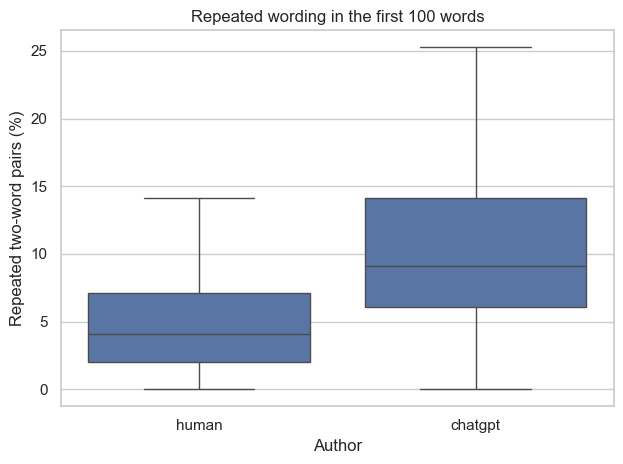

High-repetition human example | reddit_eli5 | question ID 2229 | 44.4%:
There are two possibilities : * There is a God * , or * there is no God . * Then two more possibilities : * You believe in God * , or * you do n't believe in God . * Then you get 4 possible situations and you analyze the " consequences " . ( [ Nice grid here ] ( URL_0 ) ) * * There is a God and you believe in God * * : You go to heaven * * There is a God and you do n't believe in God * * : You go to hell / No awesome afterlife for you * * There is no God and you believe in God :* * You get nothi … [excerpt]
High-repetition chatgpt example | finance | question ID 21748 | 56.6%:
There are several websites that provide real-time bond prices. Some options include:Bloomberg: Bloomberg is a financial news and data provider that offers real-time bond prices and other financial information.Yahoo Finance: Yahoo Finance is a financial news and data provider that offers real-time bond prices and other financial information.Ma

In [10]:
repetition_text = answers["text"].str.replace(
    r"\s+(n['’]t\b|['’](?:s|m|re|ve|ll|d)\b)", r"\1", regex=True
)
repetition_tokens = repetition_text.map(lambda text: word_pattern.findall(text.lower()))
def repeated_pair_percent(words):
    if len(words) < 100:
        return np.nan
    pairs = list(zip(words[:99], words[1:100]))
    return (len(pairs) - len(set(pairs))) / len(pairs) * 100
answers["repeated_pair_percent"] = repetition_tokens.map(repeated_pair_percent)
repetition_summary = answers.groupby("label")["repeated_pair_percent"].agg(
    answers_measured="count", mean_repeated_pair_percent="mean", median_repeated_pair_percent="median"
).reindex(LABELS)
repetition_summary["class_answers_included_percent"] = repetition_summary["answers_measured"] / answers["label"].value_counts().reindex(LABELS) * 100
display(repetition_summary.round(2))
sns.boxplot(data=answers, x="label", y="repeated_pair_percent", order=LABELS, showfliers=False)
plt.xlabel("Author"); plt.ylabel("Repeated two-word pairs (%)")
plt.title("Repeated wording in the first 100 words"); plt.tight_layout(); plt.show()
for label in LABELS:
    examples = answers[answers["label"].eq(label)].dropna(subset=["repeated_pair_percent"])
    if not examples.empty:
        example = examples.nlargest(1, "repeated_pair_percent").iloc[0]
        print(f"High-repetition {label} example | {example['source']} | question ID {example['id']} | {example['repeated_pair_percent']:.1f}%:")
        print(example["text"][:500] + (" … [excerpt]" if len(example["text"]) > 500 else ""))


### Compare how much answers reuse question words

Do answers repeat the question's topic words? Remove common English words such as “the” and “and”, then calculate the percentage of distinct question words that also appear in the answer. If a question has four remaining words and the answer uses three, its score is 75%.

Questions with no remaining words receive no score. This measures shared vocabulary, not correctness or understanding. Longer answers have more chances to include the question words; the second table compares answers in similar length groups.

**Use for the project:** this can expose a difference in how the two classes respond to prompts. Our answer-only detector cannot use this feature unless a question is also provided, so use it to understand the dataset and plan a possible question-aware experiment.


,answers_measured,mean_question_word_reuse_percent,median_question_word_reuse_percent
label,,,
human,45741,22.66,19.05
chatgpt,21485,51.36,46.15


Question-word reuse within answer-length groups (count and median %):


count  median
answer_length  label                 
Under 50 words chatgpt    399   66.67
               human    15912   10.00
50–99 words    chatgpt   2099   52.94
               human    12326   18.18
100–199 words  chatgpt  11840   42.86
               human    10110   25.00
200+ words     chatgpt   7147   50.00
               human     7393   35.29

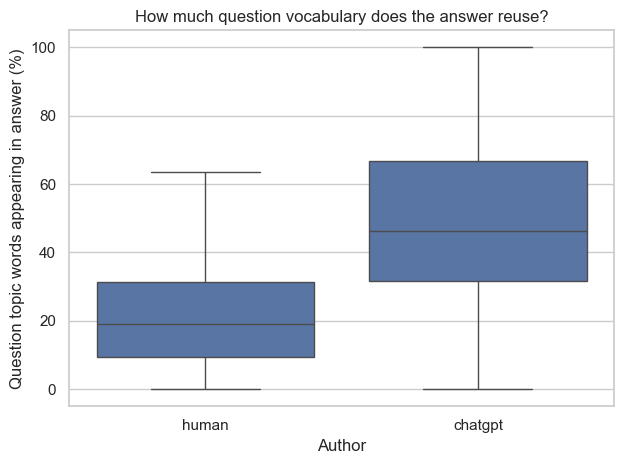

In [11]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
question_words_by_id = {
    row.id: set(word_pattern.findall(row.question.lower())) - ENGLISH_STOP_WORDS
    for row in answers[["id", "question"]].drop_duplicates("id").itertuples(index=False)
}
question_words = answers["id"].map(question_words_by_id)
answers["question_word_reuse_percent"] = [
    len(question_set & set(answer_tokens)) / len(question_set) * 100 if question_set else np.nan
    for question_set, answer_tokens in zip(question_words, tokens)
]
reuse_summary = answers.groupby("label")["question_word_reuse_percent"].agg(
    answers_measured="count", mean_question_word_reuse_percent="mean", median_question_word_reuse_percent="median"
).reindex(LABELS)
display(reuse_summary.round(2))
reuse_length_group = pd.cut(answers["word_count"], [0, 50, 100, 200, np.inf],
                           labels=["Under 50 words", "50–99 words", "100–199 words", "200+ words"], right=False)
print("Question-word reuse within answer-length groups (count and median %):")
display(answers.groupby([reuse_length_group.rename("answer_length"), "label"], observed=True)["question_word_reuse_percent"].agg(["count", "median"]).round(2))
sns.boxplot(data=answers, x="label", y="question_word_reuse_percent", order=LABELS, showfliers=False)
plt.xlabel("Author"); plt.ylabel("Question topic words appearing in answer (%)")
plt.title("How much question vocabulary does the answer reuse?")
plt.tight_layout(); plt.show()


### Compare how answers begin

Do human and ChatGPT answers start in different ways? Show the ten most common opening three-word phrases in each class. Percentages use all answers in that class as the denominator; answers with fewer than three words contribute no opening phrase.

**Use for the project:** repeated openings can reveal templates a word-based detector may learn. These are dataset patterns, not proof of authorship. Opening phrases can also reflect the topic or the way the text was stored.


Most common human openings; 6 answers have fewer than three words:


,opening_phrase,answer_count,percent_of_class_answers
0,a lot of,144,0.31
1,there is a,114,0.25
2,there are a,112,0.24
3,this is a,109,0.24
4,in addition to,97,0.21
5,i don't know,95,0.21
6,there are two,94,0.21
7,there is no,82,0.18
8,it depends on,80,0.17
9,i'm not sure,80,0.17


Most common chatgpt openings; 5 answers have fewer than three words:


,opening_phrase,answer_count,percent_of_class_answers
0,there are a,667,3.10
1,there are several,441,2.05
2,it is not,320,1.49
3,i'm sorry but,277,1.29
4,it is generally,229,1.07
5,there are many,228,1.06
6,it is possible,202,0.94
7,i'm sorry to,162,0.75
8,it's important to,129,0.60
9,in the united,129,0.60


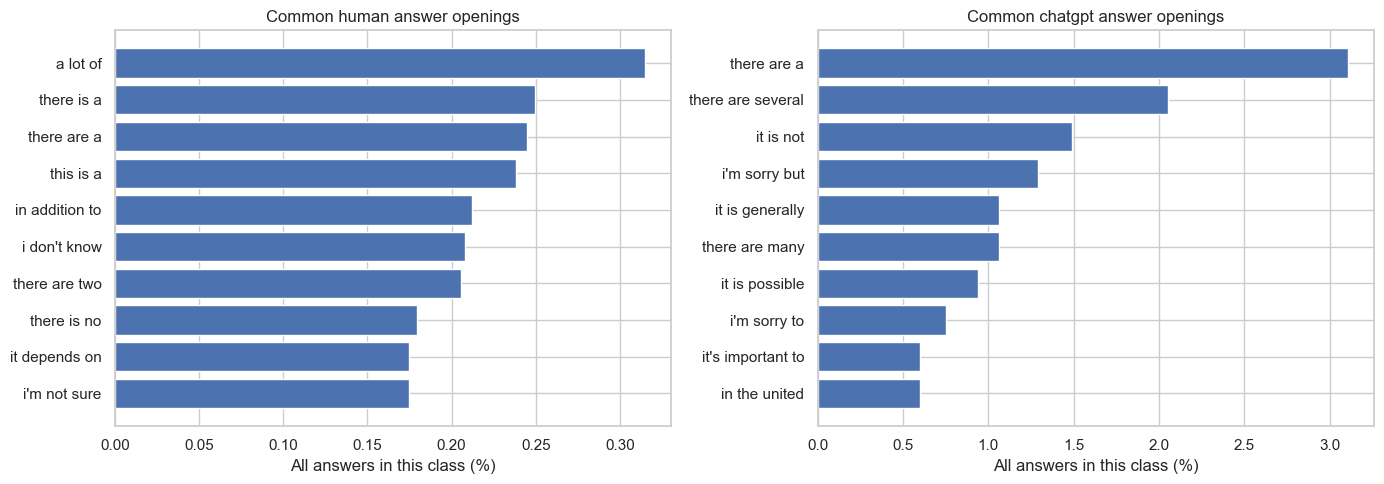

In [12]:
opening_text = answers["text"].str.replace(
    r"\s+(n['’]t\b|['’](?:s|m|re|ve|ll|d)\b)", r"\1", regex=True
)
opening_tokens = opening_text.map(lambda text: word_pattern.findall(text.lower()))
opening_phrases = opening_tokens.map(lambda words: " ".join(words[:3]) if len(words) >= 3 else None)
opening_tables = []
for label in LABELS:
    mask = answers["label"].eq(label)
    counts = opening_phrases[mask].value_counts().head(10)
    table = counts.rename_axis("opening_phrase").reset_index(name="answer_count")
    table["percent_of_class_answers"] = table["answer_count"] / mask.sum() * 100
    table["label"] = label
    opening_tables.append(table)
    print(f"Most common {label} openings; {opening_phrases[mask].isna().sum():,} answers have fewer than three words:")
    display(table.drop(columns="label").round(2))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for table, label, ax in zip(opening_tables, LABELS, axes):
    ax.barh(table["opening_phrase"], table["percent_of_class_answers"])
    ax.invert_yaxis(); ax.set_title(f"Common {label} answer openings")
    ax.set_xlabel("All answers in this class (%)")
plt.tight_layout(); plt.show()


### Compare cautious and strong wording

How often do answers include cautious words such as “may”, “might”, and “possibly”, or strong words such as “always”, “never”, and “definitely”? Count answers containing at least one word from each displayed list. An answer can belong to both groups.

**Use for the project:** these are simple candidate vocabulary features. They measure word choice, not actual confidence or correctness: “May” can be a month, and “never” can appear in a quote or warning. The domain table helps check whether a pooled difference is consistent across topics.


Cautious wording: could, generally, may, might, perhaps, possibly, probably, usually
Strong wording: absolutely, always, certainly, definitely, never, undoubtedly


Answers containing at least one listed word (%):


label,human,chatgpt
Cautious wording,32.87,59.85
Strong wording,11.21,9.33


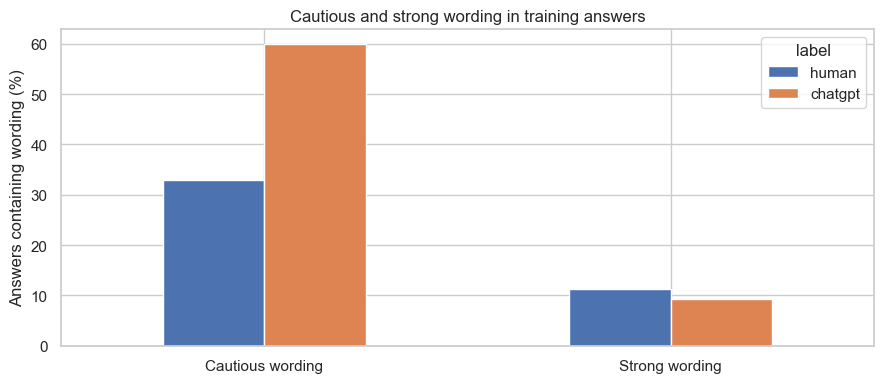

Same comparison by domain and author (%):


Cautious wording  Strong wording
source      label                                    
finance     chatgpt             78.78           13.35
            human               54.26           16.75
medicine    chatgpt             84.64           13.01
            human               44.99            4.51
open_qa     chatgpt             22.82            2.29
            human                7.79            0.53
reddit_eli5 chatgpt             61.96            9.75
            human               31.37           11.31
wiki_csai   chatgpt             34.27            3.41
            human               39.76            4.15

In [13]:
wording_groups = {
    "Cautious wording": {"may", "might", "could", "possibly", "perhaps", "probably", "usually", "generally"},
    "Strong wording": {"always", "never", "definitely", "certainly", "undoubtedly", "absolutely"},
}
for name, words in wording_groups.items():
    print(f"{name}: {', '.join(sorted(words))}")
wording_flags = pd.DataFrame({
    name: tokens.map(lambda words: bool(set(words) & vocabulary))
    for name, vocabulary in wording_groups.items()
})
wording_percent = wording_flags.groupby(answers["label"]).mean().T.reindex(columns=LABELS) * 100
print("Answers containing at least one listed word (%):")
display(wording_percent.round(2))
wording_percent.plot.bar(figsize=(9, 4), rot=0)
plt.ylabel("Answers containing wording (%)"); plt.xlabel("")
plt.title("Cautious and strong wording in training answers")
plt.tight_layout(); plt.show()
print("Same comparison by domain and author (%):")
display((wording_flags.groupby([answers["source"], answers["label"]]).mean() * 100).round(2))


## Are short answers mostly human or AI?

Put answers into simple word-count groups. The first chart shows how common each length is **within each author group**. The table also shows the human/AI mix inside each length group. This helps identify where the detector has little text to work with and whether it could rely too heavily on answer length. A length group containing both classes cannot identify the author by itself.


Number of training answers in each length group:


label,human,chatgpt
length_group,,
0–19 words,4500,129
20–49 words,11413,270
50–99 words,12326,2100
100–199 words,10111,11842
200+ words,7393,7148


Author mix within each length group (%):


label,human,chatgpt
length_group,,
0–19 words,97.2,2.8
20–49 words,97.7,2.3
50–99 words,85.4,14.6
100–199 words,46.1,53.9
200+ words,50.8,49.2


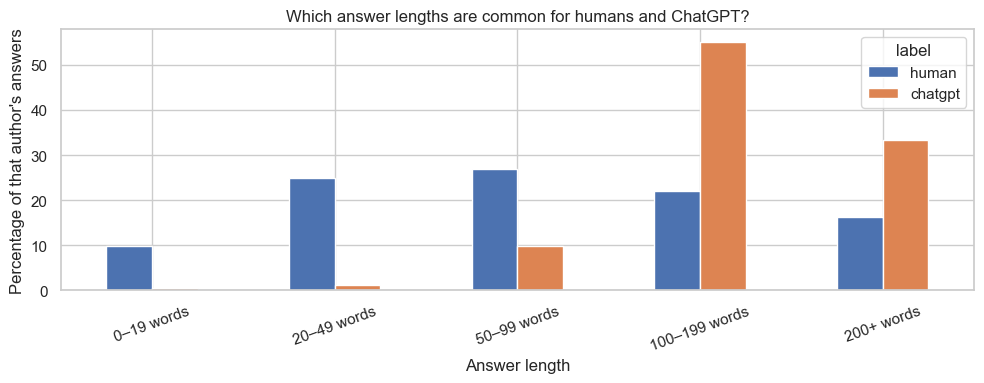

**What this means:** 9.8% of human answers and 0.6% of ChatGPT answers have fewer than 20 words. When evaluating the detector, report results separately for short answers as well as overall. The class-mix table reflects this dataset's unequal class sizes; it is not a general probability that a short answer is human.

In [14]:
answers["length_group"] = pd.cut(
    answers["word_count"], bins=[0, 20, 50, 100, 200, np.inf],
    labels=["0–19 words", "20–49 words", "50–99 words", "100–199 words", "200+ words"], right=False
)
length_counts = pd.crosstab(answers["length_group"], answers["label"]).reindex(columns=LABELS, fill_value=0)
length_within_author = length_counts.div(length_counts.sum(axis=0), axis=1) * 100
length_class_mix = length_counts.div(length_counts.sum(axis=1), axis=0) * 100
print("Number of training answers in each length group:")
display(length_counts)
print("Author mix within each length group (%):")
display(length_class_mix.round(1))
length_within_author.plot.bar(figsize=(10, 4), rot=20)
plt.ylabel("Percentage of that author's answers")
plt.xlabel("Answer length")
plt.title("Which answer lengths are common for humans and ChatGPT?")
plt.tight_layout(); plt.show()
short_pct = length_within_author.iloc[0]
display(Markdown(
    f"**What this means:** {short_pct['human']:.1f}% of human answers and {short_pct['chatgpt']:.1f}% of ChatGPT answers have fewer than 20 words. "
    "When evaluating the detector, report results separately for short answers as well as overall. "
    "The class-mix table reflects this dataset's unequal class sizes; it is not a general probability that a short answer is human."
))


## Which phrases appear more often in human or AI answers?

Count the percentage of answers containing each two- or three-word phrase. A phrase counts once per answer, even if repeated. Compare percentages rather than raw totals because there are more human answers. Keep phrases appearing in at least 1% of either class, then show the biggest differences in each direction.

This helps explain what a word-based detector might pick up. These phrases are possible clues, not rules: topic, answer length, and the dataset's sources can all affect them.

For phrase counting only, join spaced contraction endings (for example, `do n't` → `don't` and `it 's` → `it's`). This avoids presenting tokenization fragments as meaningful phrases. Dataset files remain unchanged.


Phrases more common in human answers (% of answers containing the phrase):


,phrase,human_percent,chatgpt_percent,ai_minus_human_percentage_points
587,going to,4.56,0.80,-3.76
618,have to,7.85,4.20,-3.65
121,all the,6.06,2.60,-3.46
674,i think,3.44,0.07,-3.37
669,i have,3.30,0.09,-3.21
353,but the,4.67,1.90,-2.77
1937,you get,3.56,0.99,-2.57
666,i don't,2.92,0.38,-2.54
1535,the us,3.28,0.79,-2.49
1051,most of,3.15,0.72,-2.42


Phrases more common in ChatGPT answers (% of answers containing the phrase):


,phrase,human_percent,chatgpt_percent,ai_minus_human_percentage_points
705,important to,0.76,30.49,29.72
889,it is,14.55,42.88,28.34
1331,such as,3.84,31.93,28.09
780,is a,17.16,42.55,25.39
372,can be,8.25,30.74,22.48
1118,of the,32.20,51.74,19.55
740,in the,27.62,45.59,17.97
928,it's important,0.33,16.53,16.20
929,it's important to,0.25,16.05,15.79
816,is important,0.56,15.04,14.48


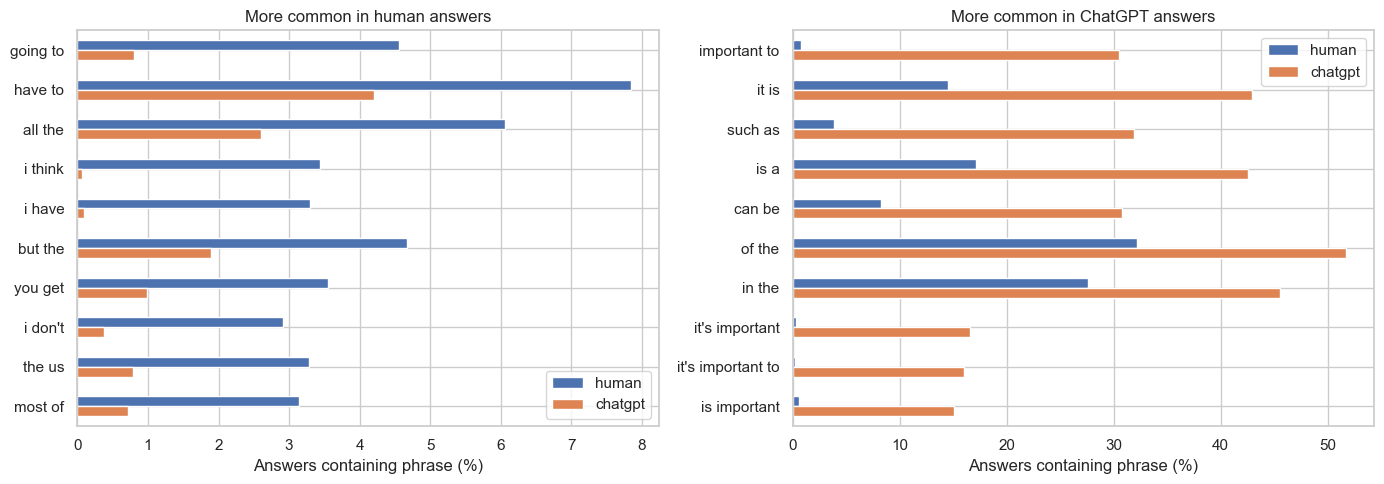

Does the phrase 'important to' show the same pattern in each domain? (% of answers)


label,chatgpt,human
source,,
finance,57.71,1.27
medicine,86.43,0.80
open_qa,9.37,0.00
reddit_eli5,24.47,0.75
wiki_csai,5.34,0.15


In [15]:
phrase_text = answers["text"].str.replace(
    r"\s+(n['’]t\b|['’](?:s|m|re|ve|ll|d)\b)", r"\1", regex=True
)
phrase_tokens = phrase_text.map(lambda text: word_pattern.findall(text.lower()))
phrase_counts = {}
for label in LABELS:
    counts = Counter()
    for words in phrase_tokens[answers["label"].eq(label)]:
        phrases = {" ".join(words[i:i+size]) for size in (2, 3) for i in range(len(words)-size+1)}
        counts.update(phrases)
    phrase_counts[label] = counts
class_sizes = answers["label"].value_counts()
common_phrases = {phrase for label in LABELS for phrase, count in phrase_counts[label].items()
                  if count / class_sizes[label] >= .01}
phrase_table = pd.DataFrame([
    {"phrase": phrase, "human_percent": phrase_counts["human"][phrase] / class_sizes["human"] * 100,
     "chatgpt_percent": phrase_counts["chatgpt"][phrase] / class_sizes["chatgpt"] * 100}
    for phrase in sorted(common_phrases)
])
phrase_table["ai_minus_human_percentage_points"] = phrase_table["chatgpt_percent"] - phrase_table["human_percent"]
human_phrases = phrase_table[phrase_table["ai_minus_human_percentage_points"].lt(0)].nsmallest(10, "ai_minus_human_percentage_points")
ai_phrases = phrase_table[phrase_table["ai_minus_human_percentage_points"].gt(0)].nlargest(10, "ai_minus_human_percentage_points")
print("Phrases more common in human answers (% of answers containing the phrase):")
display(human_phrases.round(2))
print("Phrases more common in ChatGPT answers (% of answers containing the phrase):")
display(ai_phrases.round(2))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for table, title, ax in [(human_phrases, "More common in human answers", axes[0]),
                         (ai_phrases, "More common in ChatGPT answers", axes[1])]:
    table.set_index("phrase")[["human_percent", "chatgpt_percent"]].rename(
        columns={"human_percent": "human", "chatgpt_percent": "chatgpt"}).plot.barh(ax=ax)
    ax.invert_yaxis(); ax.set_title(title); ax.set_xlabel("Answers containing phrase (%)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
# Check the strongest AI-associated phrase within each domain.
if not ai_phrases.empty:
    top_phrase = ai_phrases.iloc[0]["phrase"]
    phrase_words = top_phrase.split()
    has_phrase = phrase_tokens.map(lambda words: any(words[i:i+len(phrase_words)] == phrase_words
                                              for i in range(len(words)-len(phrase_words)+1)))
    print(f"Does the phrase '{top_phrase}' show the same pattern in each domain? (% of answers)")
    display((answers.assign(contains_phrase=has_phrase).groupby(["source", "label"])["contains_phrase"].mean().unstack() * 100).round(2))


## Do humans and AI use different conversational styles?

Compare easy-to-understand patterns: talking about yourself, addressing the reader, using contractions, asking questions, and including links. Each number is the percentage of answers containing at least one match. These simple searches miss some wording and can match quoted text, so treat them as descriptive clues.

The domain table checks whether a pattern is consistent across topics. This can help decide which writing features to investigate and where a detector needs extra evaluation.


Training answers containing each pattern (%):


label,human,chatgpt
"First-person words (I, me, my, we, us, our)",46.75,20.75
"Addressing reader (you, your)",55.97,46.54
"Contractions (don't, I'm, it's, etc.)",64.33,55.48
Question mark,13.29,5.17
Exclamation mark,6.08,10.77
Website link,0.64,0.13


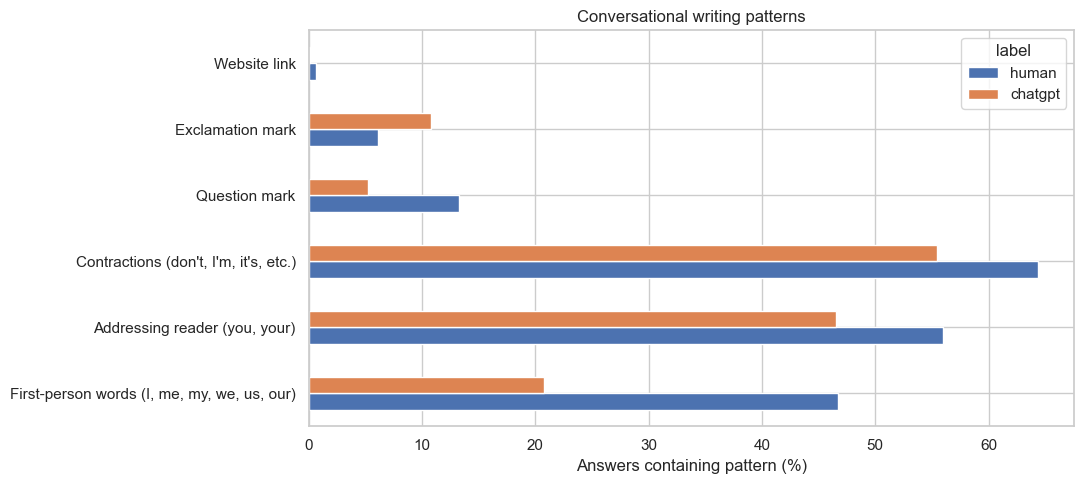

Same patterns by domain and author (%):


First-person words (I, me, my, we, us, our)  \
source      label                                                  
finance     chatgpt                                         8.28   
            human                                          61.63   
medicine    chatgpt                                        24.69   
            human                                          66.83   
open_qa     chatgpt                                         9.02   
            human                                           3.79   
reddit_eli5 chatgpt                                        26.65   
            human                                          46.66   
wiki_csai   chatgpt                                        13.80   
            human                                          13.06   

                     Addressing reader (you, your)  \
source      label                                    
finance     chatgpt                          70.89   
            human                            83.63   
medicine    chatgpt                          94.53   
            human                            89.38   
open_qa     chatgpt                          10.92   
            human                             0.42   
reddit_eli5 chatgpt                          45.81   
            human                            55.22   
wiki_csai   chatgpt                           5.64   
            human                             0.59   

                     Contractions (don't, I'm, it's, etc.)  Question mark  \
source      label                                                           
finance     chatgpt                                  64.29           3.79   
            human                                    70.18          20.66   
medicine    chatgpt                                  56.27           1.89   
            human                                    14.73           4.31   
open_qa     chatgpt                                  31.45           2.11   
            human                                     9.89           0.21   
reddit_eli5 chatgpt                                  59.74           6.63   
            human                                    66.96          13.44   
wiki_csai   chatgpt                                  24.33           1.78   
            human                                    31.16           1.78   

                     Exclamation mark  Website link  
source      label                                    
finance     chatgpt              2.76          0.53  
            human                6.68          6.99  
medicine    chatgpt              2.73          0.00  
            human                5.81          5.41  
open_qa     chatgpt              1.13          0.04  
            human                0.32          0.00  
reddit_eli5 chatgpt             16.13          0.07  
            human                6.27          0.05  
wiki_csai   chatgpt              0.74          0.00  
            human                0.59          0.00

In [16]:
writing_patterns = {
    "First-person words (I, me, my, we, us, our)": r"\b(?:i|me|my|we|us|our)\b",
    "Addressing reader (you, your)": r"\b(?:you|your)\b",
    "Contractions (don't, I'm, it's, etc.)": r"\b[a-z]+(?:\s+n['’]t|\s*['’](?:t|s|re|ve|ll|d|m))\b",
    "Question mark": r"\?",
    "Exclamation mark": r"!",
    "Website link": r"https?://|www\.",
}
style_flags = pd.DataFrame({name: answers["text"].str.contains(pattern, case=False, regex=True)
                            for name, pattern in writing_patterns.items()})
style_percent = style_flags.groupby(answers["label"]).mean().T.reindex(columns=LABELS) * 100
print("Training answers containing each pattern (%):")
display(style_percent.round(2))
style_percent.plot.barh(figsize=(11, 5))
plt.xlabel("Answers containing pattern (%)"); plt.ylabel("")
plt.title("Conversational writing patterns"); plt.tight_layout(); plt.show()
print("Same patterns by domain and author (%):")
display((style_flags.groupby([answers["source"], answers["label"]]).mean() * 100).round(2))


## Compare word length

Do human and ChatGPT answers use different mixes of short and long words? Group words by the number of letters:

- **Short:** 1–3 letters, such as “the” and “you”.
- **Medium:** 4–6 letters, such as “people” and “answer”.
- **Long:** 7 or more letters, such as “because” and “information”.

The chart shows each group's share of all words written by that class. Percentages make the classes easier to compare despite their different sizes. The table also gives each answer equal weight when measuring average word length and the percentage of long words; the chart gives longer answers more weight because they contain more words.

**Why this helps:** average word length and the share of long words are simple candidate text features. Compare them by topic before using them: a technical topic can naturally require longer words. Long words do not automatically mean better, harder, or AI-written text.


Word length per answer (letters; long-word share in %):


,answers_measured,mean_answer_word_length,median_answer_word_length,median_long_word_percent
label,,,,
human,45740,4.52,4.48,19.10
chatgpt,21489,4.65,4.64,22.88


Share of all words in each length group (%):


,human,chatgpt
Short (1–3),40.83,41.10
Medium (4–6),39.41,35.82
Long (7+),19.76,23.08


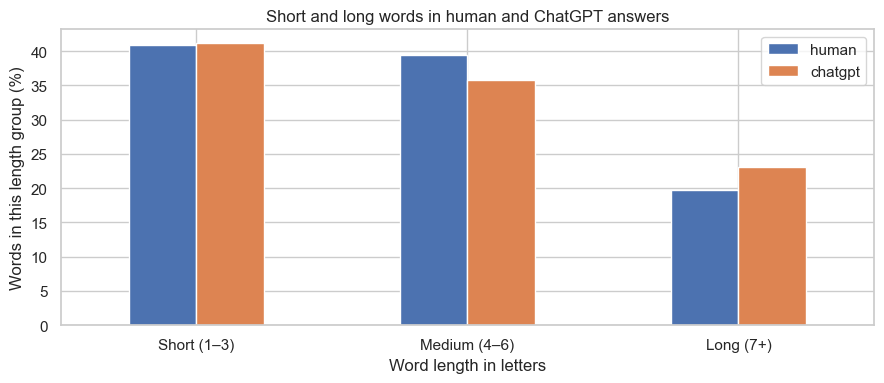

Word length by topic (median per answer):


average_word_letters  long_word_percent
source      label                                           
finance     chatgpt                  4.72              24.64
            human                    4.44              18.62
medicine    chatgpt                  4.92              28.40
            human                    4.74              23.64
open_qa     chatgpt                  4.78              25.43
            human                    4.97              27.52
reddit_eli5 chatgpt                  4.54              21.02
            human                    4.47              18.75
wiki_csai   chatgpt                  5.14              32.04
            human                    5.41              35.60

**Reading the result:** a typical human answer averages 4.48 letters per word, compared with 4.64 for ChatGPT. Check whether the direction stays the same across topics before treating word length as an author clue.

In [17]:
# Join spaced contraction endings only in this analysis; leave dataset text intact.
word_length_text = answers["text"].str.replace(
    r"\s+(n['’]t\b|['’](?:s|m|re|ve|ll|d)\b)", r"\1", regex=True
)
word_length_tokens = word_length_text.map(lambda text: word_pattern.findall(text.lower()))
# Count letters rather than apostrophes inside contractions.
letter_lengths = word_length_tokens.map(lambda words: [sum(ch.isalpha() for ch in word) for word in words])
answers["average_word_letters"] = letter_lengths.map(lambda lengths: np.mean(lengths) if lengths else np.nan)
answers["long_word_percent"] = letter_lengths.map(
    lambda lengths: sum(length >= 7 for length in lengths) / len(lengths) * 100 if lengths else np.nan
)
word_length_summary = answers.groupby("label").agg(
    answers_measured=("average_word_letters", "count"),
    mean_answer_word_length=("average_word_letters", "mean"),
    median_answer_word_length=("average_word_letters", "median"),
    median_long_word_percent=("long_word_percent", "median"),
).reindex(LABELS)
print("Word length per answer (letters; long-word share in %):")
display(word_length_summary.round(2))
word_size_counts = {}
for label in LABELS:
    counts = Counter()
    for lengths in letter_lengths[answers["label"].eq(label)]:
        counts.update("Short (1–3)" if length <= 3 else "Medium (4–6)" if length <= 6 else "Long (7+)"
                      for length in lengths)
    word_size_counts[label] = counts
word_size_counts = pd.DataFrame(word_size_counts).reindex(["Short (1–3)", "Medium (4–6)", "Long (7+)"], fill_value=0)
word_size_percent = word_size_counts.div(word_size_counts.sum(axis=0), axis=1) * 100
print("Share of all words in each length group (%):")
display(word_size_percent.round(2))
word_size_percent.plot.bar(figsize=(9, 4), rot=0)
plt.ylabel("Words in this length group (%)"); plt.xlabel("Word length in letters")
plt.title("Short and long words in human and ChatGPT answers")
plt.tight_layout(); plt.show()
print("Word length by topic (median per answer):")
display(answers.groupby(["source", "label"])[["average_word_letters", "long_word_percent"]].median().round(2))
display(Markdown(
    f"**Reading the result:** a typical human answer averages {word_length_summary.loc['human', 'median_answer_word_length']:.2f} letters per word, "
    f"compared with {word_length_summary.loc['chatgpt', 'median_answer_word_length']:.2f} for ChatGPT. "
    "Check whether the direction stays the same across topics before treating word length as an author clue."
))


## What should we take into model development?

The summary below connects the EDA to decisions for the detector. No model is trained here. Writing-style analysis uses only training answers; validation and test were checked only for split integrity and distributions.


In [18]:
medians = answers.groupby("label")["word_count"].median()
train_test_overlap = leakage_table[leakage_table["pair"].eq("train/test")].iloc[0]
largest_source = answers["source"].value_counts(normalize=True)
display(Markdown(
    f"- **Account for class imbalance:** humans make up {answers['label'].eq('human').mean():.1%} of training answers. Compare against a majority-class baseline and report precision/recall for both classes, plus macro F1.\n"
    f"- **Check whether length is doing the work:** median lengths are {medians['human']:.0f} words for humans and {medians['chatgpt']:.0f} for ChatGPT. Evaluate the length groups separately.\n"
    f"- **Report results by topic:** {largest_source.index[0]} supplies {largest_source.iloc[0]:.1%} of training answers. Strong overall results could hide weak results on smaller domains.\n"
    "- **Use phrase and conversational-pattern tables to explain features:** investigate these in a word-based model, but do not turn them into hard human/AI rules.\n"
    f"- **Review duplicates before trusting test scores:** train/test share {int(train_test_overlap['exact_answer_keys']):,} exact answer texts and {int(train_test_overlap['normalized_prompt_keys']):,} normalized prompts despite having separate question IDs.\n"
    "- **Use the current data version:** local generated split CSVs are checked at the start. When they are stale, regenerate them with the existing cleaning and splitting notebooks before training; this EDA does not overwrite them."
))


- **Account for class imbalance:** humans make up 68.0% of training answers. Compare against a majority-class baseline and report precision/recall for both classes, plus macro F1.
- **Check whether length is doing the work:** median lengths are 74 words for humans and 175 for ChatGPT. Evaluate the length groups separately.
- **Report results by topic:** reddit_eli5 supplies 79.3% of training answers. Strong overall results could hide weak results on smaller domains.
- **Use phrase and conversational-pattern tables to explain features:** investigate these in a word-based model, but do not turn them into hard human/AI rules.
- **Review duplicates before trusting test scores:** train/test share 879 exact answer texts and 105 normalized prompts despite having separate question IDs.
- **Use the current data version:** local generated split CSVs are checked at the start. When they are stale, regenerate them with the existing cleaning and splitting notebooks before training; this EDA does not overwrite them.